# T-test

- T-test, ANOVA는 통계 기반 데이터 분석의 기본 방법론 중 하나

- 집단 내 혹은 집단 간의 평균값 차이가 통계적으로 유의미한 것인지 알아내는 방법
    - 예) 쇼핑몰의 지역별 객단가를 분석할 경우
        - A지역의 고객별 평균 매출 : 67,000원
        - B지역의 고객별 평균 매출 : 68,500원
 
        - 이때, 1500원의 차이가 우연적인 차이인지, 통계적으로 유의미한 차이인지를 알아보기 위해 사용
 
- T-test는 두 집단 간의 평균 차이를 분석할 때 사용

- ANOVA는 두 집단 이상일 경우에 사용

- T-test는 분석하고자 하는 변수가 양적 변수이며, 정규분포이며, 등분산성이라는 조건이 충족되어야 함

- 평균의 차이가 클수록, 표본의 수가 많을수록 귀무가설이 기각될 가능성이 커지고, 관측치들의 값 간의 표준편차가 크면 평균의 차이가 불분명해지고 귀무가설이 채택될 가능성이 커짐
    - 예) 각 고객들의 마케팅 프로그램 전과 후의 매출 차이가 들쑥날쑥하면 매출 평균 차이가 우연에 의한 것일 확률이 높다고 판단

In [5]:
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# windows용 한글 폰트 오류 해결
from matplotlib import font_manager, rc
font_path = 'C:/Windows/Fonts/malgun.ttf'
font_name = font_manager.FontProperties(fname = font_path).get_name()
rc('font', family=font_name)

In [7]:
df = pd.read_csv("./data/csv/Golf_test.csv")

In [8]:
df.head()

,TypeA_before,TypeA_after,TypeB_before,TypeB_after,TypeC_before,TypeC_after
0,277,264,265,268,267,268
1,269,261,264,267,264,269
2,263,267,269,272,283,283
3,266,272,274,277,287,266
4,262,258,261,264,275,266


- A, B, C 세 개 타입의 골프공의 비거리 테스트 결과 데이터

- 각 타입의 골프공을 특정 처리를 하기 전과 후로 구분

In [9]:
# 골프공 타입별 통계값 확인
df.describe()

,TypeA_before,TypeA_after,TypeB_before,TypeB_after,TypeC_before,TypeC_after
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,268.460000,270.720000,273.600000,276.100000,270.360000,271.040000
std,9.817124,8.487782,8.566665,8.493094,8.385507,9.437139
min,250.000000,255.000000,258.000000,261.000000,255.000000,253.000000
25%,262.000000,264.000000,266.250000,269.000000,263.250000,265.000000
50%,266.000000,271.000000,273.500000,276.500000,268.500000,268.000000
75%,275.750000,275.000000,278.000000,280.000000,275.750000,277.750000
max,289.000000,289.000000,292.000000,295.000000,289.000000,291.000000


- 평균값은 270 내외의 값을 가지고 있으며, before보다 after가 큰 경향이 있음

- B, C, A 순으로 평균값이 큼

- 비거리 평균의 차이가 통계적으로 유의미한 차이인지 확인

In [12]:
df2 = pd.melt(df)

In [13]:
df2.head()

,variable,value
0,TypeA_before,277
1,TypeA_before,269
2,TypeA_before,263
3,TypeA_before,266
4,TypeA_before,262


In [14]:
df.shape

(50, 6)

In [15]:
df2.shape

(300, 2)

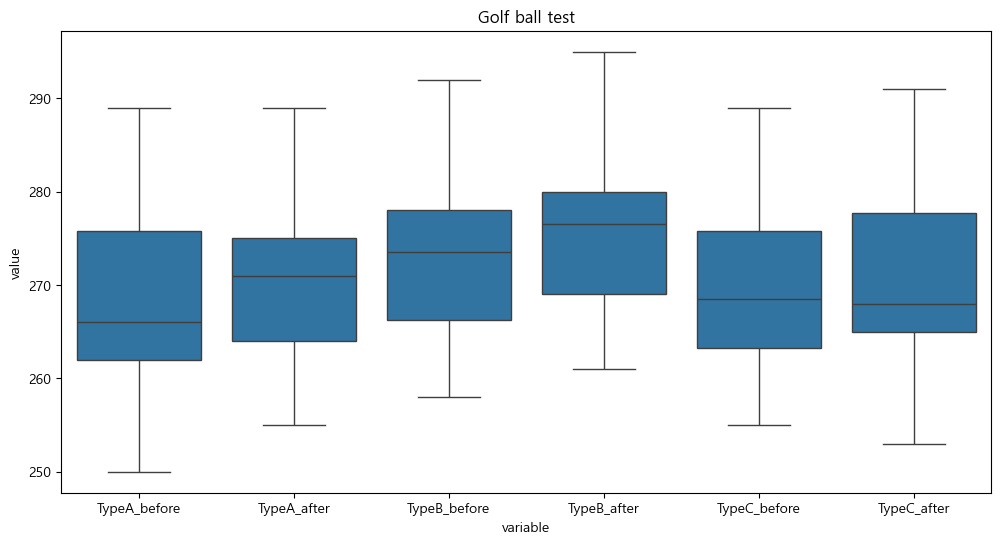

In [16]:
# 그룹별 박스플롯 시각화
plt.figure(figsize = (12, 6))
sns.boxplot(x = "variable", y = "value", data = df2)
plt.title("Golf ball test")

plt.show()

- 컬럼별 차이를 직관적으로 확인하기 위해 박스플롯 시각화

- TypeA_before와 TypeA_after는 중앙값은 차이가 나지만 분포는 유사함

In [18]:
# 데이터 정규성 검정
print(stats.shapiro(df["TypeA_before"]))
print(stats.shapiro(df["TypeA_after"]))

print(stats.shapiro(df["TypeB_before"]))
print(stats.shapiro(df["TypeB_after"]))

print(stats.shapiro(df["TypeC_before"]))
print(stats.shapiro(df["TypeC_after"]))

ShapiroResult(statistic=np.float64(0.9655377158052212), pvalue=np.float64(0.15154941346876938))
ShapiroResult(statistic=np.float64(0.9728279567361319), pvalue=np.float64(0.30051020169283893))
ShapiroResult(statistic=np.float64(0.9730037974106026), pvalue=np.float64(0.305345354286895))
ShapiroResult(statistic=np.float64(0.9693011028933032), pvalue=np.float64(0.2167560294629035))
ShapiroResult(statistic=np.float64(0.9595516780117022), pvalue=np.float64(0.08512947305030288))
ShapiroResult(statistic=np.float64(0.946983211173158), pvalue=np.float64(0.02568194780152731))


- p-value 값이 0.05를 초과하면 정규성을 만족

- p-value 값이 0.05를 초과하지 않으면 정규성을 만족하지 않음
    - TypeC_after는 정규성을 가지지 못하기 때문에 이상치 처리나 스케일링 등을 적용하여 정규성을 갖도록 가공 가능

In [19]:
# 데이터 등분산성 검정
stats.bartlett(df["TypeA_before"], df["TypeA_after"],
              df["TypeB_before"], df["TypeB_after"],
              df["TypeC_before"], df["TypeC_after"])

BartlettResult(statistic=np.float64(6.11310221158456), pvalue=np.float64(0.2953686646014157))

- p-value가 0.05를 초과하면 등분산성을 만족

In [20]:
# 대응표본 t검정 수행
stats.ttest_rel(df["TypeA_before"], df["TypeA_after"])

TtestResult(statistic=np.float64(-1.221439914972903), pvalue=np.float64(0.227763764486876), df=np.int64(49))

- pvalue가 0.05를 초과하여 평균의 차이가 통계적으로 유의미하지 않음
    - 즉, TypeA 골프공은 특정 처리를 하기 전과 후의 비거리가 통계적으로 차이가 없음

In [21]:
stats.ttest_rel(df["TypeB_before"], df["TypeB_after"])

TtestResult(statistic=np.float64(-34.99999999999999), pvalue=np.float64(2.4886054257756526e-36), df=np.int64(49))

In [22]:
stats.ttest_rel(df["TypeC_before"], df["TypeC_after"])

TtestResult(statistic=np.float64(-0.3563992607439856), pvalue=np.float64(0.7230716735469858), df=np.int64(49))

In [23]:
# 독립표본 t검정 수행
stats.ttest_ind(df["TypeA_before"], df["TypeA_after"], equal_var = True)

TtestResult(statistic=np.float64(-1.2313987682249838), pvalue=np.float64(0.2211206199970269), df=np.float64(98.0))

- pvalue가 0.05보다 작아 A와 B 두 집단 간에는 통계적으로 유의미한 차이 존재

- 대응표본 t검정과 독립표본 t검정의 차이

|| 독립표본 t-검정 | 대응표본 t-검정 |
| :-- | :-- | :-- |
| 비교 대상 | 서로 다른 두 그룹 비교 | 같은 집단에서 두 번 측정(전후 비교) |
| 데이터 특징 | 두 그룹이 서로 독립적 | 같은 개체에서 반복 측정 |
| 예시 | A회사와 B회사의 직원 평균 연봉 비교 | 운동 전후 체중 변화 비교 |
| 함수 | ttest_ind | ttest_rel |
